In [ ]:
import torch
import torch.nn as nn
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_error

# Configuration

In [ ]:
# Choose input type: 'tif' or 'pth'
INPUT_TYPE = 'pth'  # Change to 'pth' to load from model file

# If INPUT_TYPE = 'tif', specify prediction file
PREDICTION_TIF = 'READY_data/predictions/predicted_cisi_2024_025.tif'

# If INPUT_TYPE = 'pth', specify model file
MODEL_PTH = 'models\cisi_model_exp104.pth'

# Ground truth (always needed)
ACTUAL_CISI = r"READY_data\labels\2024_CISI_010deg_nearest.tif"

# Data paths (only needed if INPUT_TYPE = 'pth')
DATA_PATHS = {
    'gdp': r"READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif",
    'pop': r"READY_data\inputs_normalized\2020_pop_aligned_010_normalized.tif",
    'lc': r"READY_data\landuse_onehot\chen2015_lc_onehot.tif",
}

# Analysis parameters
HIGH_CISI_THRESHOLD = 0.1  # Define "cities" as CISI > 0.1

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Input type: {INPUT_TYPE}")

# Model Architecture

In [ ]:
class CNN(nn.Module):
    def __init__(self, config):
        super(CNN, self).__init__()

        self.config = config

        # 3 Layers of the CNN
        self.conv_layers = nn.Sequential(
            nn.Conv2d(9, 16, kernel_size=3, padding=1), # 9 channels
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),
        )

        # Makes model patch-size independent
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Fully connected regression head
        self.fc_layers = nn.Sequential(
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.fc_layers(x)

        # Temperature scaling
        temperature = 2.5  # Higher = less squashing
        x = torch.sigmoid(x / temperature)
        # x = torch.sigmoid(x) # Sigmoid activation function
        # x = torch.clamp(x, 0, 1) # Linear clip to valid range
        return x

def load_model(model_path, device):
    """Load trained model from .pth file"""
    config = {'dropout': 0.3}
    model = CNN(config).to(device)
    
    checkpoint = torch.load(model_path, map_location=device)
    
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    
    model.eval()
    print(f"Model loaded from {model_path}")
    return model

def generate_predictions(model, gdp, pop, lc, device, patch_size=32):
    """Generate predictions from model"""
    H, W = gdp.shape
    predictions = np.full((H, W), np.nan, dtype=np.float32)
    
    half_patch = patch_size // 2
    valid_mask = ~np.isnan(gdp) & ~np.isnan(pop)
    valid_indices = np.argwhere(valid_mask)
    
    print(f"Generating predictions for {len(valid_indices):,} pixels...")
    
    model.eval()
    with torch.no_grad():
        for idx, (i, j) in enumerate(valid_indices):
            i_start = max(0, i - half_patch)
            i_end = min(H, i + half_patch)
            j_start = max(0, j - half_patch)
            j_end = min(W, j + half_patch)
            
            gdp_patch = gdp[i_start:i_end, j_start:j_end].copy()
            pop_patch = pop[i_start:i_end, j_start:j_end].copy()
            lc_patch = lc[:, i_start:i_end, j_start:j_end].copy()
            
            gdp_patch = np.nan_to_num(gdp_patch, nan=0.0)
            pop_patch = np.nan_to_num(pop_patch, nan=0.0)
            
            pad_i = patch_size - gdp_patch.shape[0]
            pad_j = patch_size - gdp_patch.shape[1]
            
            if pad_i > 0 or pad_j > 0:
                gdp_patch = np.pad(gdp_patch, ((0, pad_i), (0, pad_j)))
                pop_patch = np.pad(pop_patch, ((0, pad_i), (0, pad_j)))
                lc_patch = np.pad(lc_patch, ((0, 0), (0, pad_i), (0, pad_j)))
            
            input_tensor = np.stack([gdp_patch, pop_patch, *lc_patch], axis=0)
            input_tensor = torch.FloatTensor(input_tensor).unsqueeze(0).to(device)
            
            prediction = model(input_tensor).cpu().item()
            predictions[i, j] = prediction
            
            if (idx + 1) % 2000 == 0:
                print(f"  {idx + 1:,} / {len(valid_indices):,}")
    
    print("Predictions complete")
    return predictions

# Helper Functions

# Load data

In [ ]:
# Load predictions based on INPUT_TYPE
if INPUT_TYPE == 'tif':
    # Load from .tif file
    with rasterio.open(PREDICTION_TIF) as src:
        predictions = src.read(1)
        profile = src.profile
    print(f"Loaded predictions from: {PREDICTION_TIF}")
    
elif INPUT_TYPE == 'pth':
    # Load model and generate predictions
    model = load_model(MODEL_PTH, device)
    
    # Load input data
    with rasterio.open(DATA_PATHS['gdp']) as src:
        gdp = src.read(1).astype(np.float32)
        profile = src.profile
    
    with rasterio.open(DATA_PATHS['pop']) as src:
        pop = src.read(1).astype(np.float32)
    
    with rasterio.open(DATA_PATHS['lc']) as src:
        lc = src.read().astype(np.float32)
    
    # Generate predictions
    predictions = generate_predictions(model, gdp, pop, lc, device)
    
else:
    raise ValueError(f"Invalid INPUT_TYPE: {INPUT_TYPE}")

# Load ground truth
with rasterio.open(ACTUAL_CISI) as src:
    actuals = src.read(1)

print(f"Predictions shape: {predictions.shape}")
print(f"Actuals shape: {actuals.shape}")

# Mask predictions to only show where CISI labels exist
valid_comparison_mask = ~np.isnan(predictions) & ~np.isnan(actuals)
predictions = np.where(valid_comparison_mask, predictions, np.nan)
actuals = np.where(valid_comparison_mask, actuals, np.nan)

print(f"Valid comparison pixels: {valid_comparison_mask.sum():,}")

Model loaded from models\cisi_model_exp27.pth
Generating predictions for 14,259 pixels...
  2,000 / 14,259
  4,000 / 14,259
  6,000 / 14,259
  8,000 / 14,259
  10,000 / 14,259
  12,000 / 14,259
  14,000 / 14,259
Predictions complete
Predictions shape: (194, 228)
Actuals shape: (194, 228)
Valid comparison pixels: 11,944


# Analysis functions

In [ ]:
def calculate_pixel_errors(predictions, actuals, threshold_high_cisi=0.1):
    """
    Calculate various error metrics per pixel.
    
    Returns dict with error maps.
    """
    # Basic errors
    absolute_error = np.abs(predictions - actuals)
    squared_error = (predictions - actuals) ** 2
    relative_error = np.where(
        actuals > 0.001,  # Avoid division by zero
        absolute_error / actuals,
        np.nan
    )
    
    # Identify high CISI areas (cities)
    high_cisi_mask = actuals > threshold_high_cisi
    
    # Weighted errors (penalize city errors more)
    # Quadratic weighting: weight = 1 + 10 * CISI²
    quadratic_weights = 1 + 10 * (actuals ** 2)
    weighted_squared_error_quad = quadratic_weights * squared_error
    
    # Exponential weighting: weight = exp(5 * CISI)
    exponential_weights = np.exp(5 * actuals)
    weighted_squared_error_exp = exponential_weights * squared_error
    
    # Binary city vs non-city errors
    city_errors = np.where(high_cisi_mask, absolute_error, np.nan)
    rural_errors = np.where(~high_cisi_mask, absolute_error, np.nan)
    
    return {
        'absolute_error': absolute_error,
        'squared_error': squared_error,
        'relative_error': relative_error,
        'weighted_error_quadratic': weighted_squared_error_quad,
        'weighted_error_exponential': weighted_squared_error_exp,
        'city_errors': city_errors,
        'rural_errors': rural_errors,
        'high_cisi_mask': high_cisi_mask,
        'quadratic_weights': quadratic_weights,
        'exponential_weights': exponential_weights
    }

In [ ]:
def analyze_spatial_errors(error_dict, actuals, predictions):
    """
    Analyze errors by spatial region and CISI level.
    """
    results = {}
    
    # Overall statistics
    valid_mask = ~np.isnan(error_dict['absolute_error'])
    
    results['overall'] = {
        'mae': np.nanmean(error_dict['absolute_error']),
        'rmse': np.sqrt(np.nanmean(error_dict['squared_error'])),
        'mean_relative_error': np.nanmean(error_dict['relative_error']),
        'weighted_mse_quad': np.nanmean(error_dict['weighted_error_quadratic']),
        'weighted_mse_exp': np.nanmean(error_dict['weighted_error_exponential']),
    }
    
    # City vs Rural
    results['cities'] = {
        'count': np.sum(error_dict['high_cisi_mask']),
        'mae': np.nanmean(error_dict['city_errors']),
        'rmse': np.sqrt(np.nanmean(error_dict['city_errors']**2)),
        'mean_cisi': np.nanmean(actuals[error_dict['high_cisi_mask']]),
        'mean_prediction': np.nanmean(predictions[error_dict['high_cisi_mask']]),
    }
    
    results['rural'] = {
        'count': np.sum(~error_dict['high_cisi_mask'] & valid_mask),
        'mae': np.nanmean(error_dict['rural_errors']),
        'rmse': np.sqrt(np.nanmean(error_dict['rural_errors']**2)),
        'mean_cisi': np.nanmean(actuals[~error_dict['high_cisi_mask'] & valid_mask]),
        'mean_prediction': np.nanmean(predictions[~error_dict['high_cisi_mask'] & valid_mask]),
    }
    
    # CISI bins
    cisi_bins = [0, 0.05, 0.1, 0.15, 0.2, 1.0]
    bin_labels = ['0-0.05', '0.05-0.1', '0.1-0.15', '0.15-0.2', '0.2+']
    
    results['by_cisi_level'] = {}
    
    for i, (low, high) in enumerate(zip(cisi_bins[:-1], cisi_bins[1:])):
        mask = (actuals >= low) & (actuals < high) & valid_mask
        if np.sum(mask) > 0:
            results['by_cisi_level'][bin_labels[i]] = {
                'count': np.sum(mask),
                'mae': np.nanmean(error_dict['absolute_error'][mask]),
                'rmse': np.sqrt(np.nanmean(error_dict['squared_error'][mask])),
                'mean_actual': np.nanmean(actuals[mask]),
                'mean_prediction': np.nanmean(predictions[mask]),
            }
    
    # Geographic quadrants (rough Europe regions)
    H, W = actuals.shape
    
    results['by_region'] = {
        'North': analyze_region(error_dict, actuals, predictions, 0, H//2, 0, W),
        'South': analyze_region(error_dict, actuals, predictions, H//2, H, 0, W),
        'West': analyze_region(error_dict, actuals, predictions, 0, H, 0, W//2),
        'East': analyze_region(error_dict, actuals, predictions, 0, H, W//2, W),
    }
    
    return results

def analyze_region(error_dict, actuals, predictions, row_start, row_end, col_start, col_end):
    """Helper to analyze a rectangular region."""
    region_mask = np.zeros_like(actuals, dtype=bool)
    region_mask[row_start:row_end, col_start:col_end] = True
    valid_mask = ~np.isnan(error_dict['absolute_error']) & region_mask
    
    if np.sum(valid_mask) == 0:
        return None
    
    return {
        'count': np.sum(valid_mask),
        'mae': np.nanmean(error_dict['absolute_error'][valid_mask]),
        'rmse': np.sqrt(np.nanmean(error_dict['squared_error'][valid_mask])),
        'mean_actual': np.nanmean(actuals[valid_mask]),
        'mean_prediction': np.nanmean(predictions[valid_mask]),
    }

In [ ]:
def visualize_error_maps(error_dict, actuals, predictions):
    """
    Create comprehensive error visualization.
    """
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
    
    # Row 1: Actual, Predicted, Absolute Error, Relative Error
    ax1 = fig.add_subplot(gs[0, 0])
    im1 = ax1.imshow(actuals, cmap='RdYlGn', vmin=0, vmax=0.35)
    ax1.set_title('Actual CISI', fontsize=12, fontweight='bold')
    plt.colorbar(im1, ax=ax1, fraction=0.046)
    
    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.imshow(predictions, cmap='RdYlGn', vmin=0, vmax=0.35)
    ax2.set_title('Predicted CISI', fontsize=12, fontweight='bold')
    plt.colorbar(im2, ax=ax2, fraction=0.046)
    
    ax3 = fig.add_subplot(gs[0, 2])
    im3 = ax3.imshow(error_dict['absolute_error'], cmap='hot', vmin=0, vmax=0.1)
    ax3.set_title('Absolute Error\n(Higher = Worse)', fontsize=12, fontweight='bold')
    plt.colorbar(im3, ax=ax3, fraction=0.046, label='Error')
    
    ax4 = fig.add_subplot(gs[0, 3])
    im4 = ax4.imshow(error_dict['relative_error'], cmap='hot', vmin=0, vmax=2)
    ax4.set_title('Relative Error\n(|pred-actual|/actual)', fontsize=12, fontweight='bold')
    plt.colorbar(im4, ax=ax4, fraction=0.046, label='Ratio')
    
    # Row 2: Weighted Errors
    ax5 = fig.add_subplot(gs[1, 0])
    im5 = ax5.imshow(error_dict['quadratic_weights'], cmap='viridis', vmin=1, vmax=5)
    ax5.set_title('Quadratic Weights\n(1 + 10*CISI²)', fontsize=12, fontweight='bold')
    plt.colorbar(im5, ax=ax5, fraction=0.046)
    
    ax6 = fig.add_subplot(gs[1, 1])
    im6 = ax6.imshow(error_dict['weighted_error_quadratic'], cmap='hot', vmin=0)
    ax6.set_title('Weighted Error (Quadratic)\nPenalizes Cities More', fontsize=12, fontweight='bold')
    plt.colorbar(im6, ax=ax6, fraction=0.046)
    
    ax7 = fig.add_subplot(gs[1, 2])
    # Log scale for exponential weights
    exp_weights_plot = np.log1p(error_dict['exponential_weights'])
    im7 = ax7.imshow(exp_weights_plot, cmap='viridis')
    ax7.set_title('Exponential Weights (log scale)\n(exp(5*CISI))', fontsize=12, fontweight='bold')
    plt.colorbar(im7, ax=ax7, fraction=0.046)
    
    ax8 = fig.add_subplot(gs[1, 3])
    im8 = ax8.imshow(error_dict['weighted_error_exponential'], cmap='hot', vmin=0)
    ax8.set_title('Weighted Error (Exponential)\nVery High City Penalty', fontsize=12, fontweight='bold')
    plt.colorbar(im8, ax=ax8, fraction=0.046)
    
    # Row 3: City vs Rural Focus
    ax9 = fig.add_subplot(gs[2, 0])
    im9 = ax9.imshow(error_dict['high_cisi_mask'], cmap='RdYlGn_r')
    ax9.set_title('High CISI Pixels\n(Cities, CISI > 0.1)', fontsize=12, fontweight='bold')
    plt.colorbar(im9, ax=ax9, fraction=0.046)
    
    ax10 = fig.add_subplot(gs[2, 1])
    im10 = ax10.imshow(error_dict['city_errors'], cmap='hot', vmin=0, vmax=0.1)
    ax10.set_title('City Errors Only\n(High CISI regions)', fontsize=12, fontweight='bold')
    plt.colorbar(im10, ax=ax10, fraction=0.046)
    
    ax11 = fig.add_subplot(gs[2, 2])
    im11 = ax11.imshow(error_dict['rural_errors'], cmap='hot', vmin=0, vmax=0.1)
    ax11.set_title('Rural Errors Only\n(Low CISI regions)', fontsize=12, fontweight='bold')
    plt.colorbar(im11, ax=ax11, fraction=0.046)
    
    # Difference map (over/under prediction)
    ax12 = fig.add_subplot(gs[2, 3])
    diff = predictions - actuals
    norm = TwoSlopeNorm(vmin=-0.1, vcenter=0, vmax=0.1)
    im12 = ax12.imshow(diff, cmap='RdBu_r', norm=norm)
    ax12.set_title('Prediction Bias\n(Blue=Under, Red=Over)', fontsize=12, fontweight='bold')
    plt.colorbar(im12, ax=ax12, fraction=0.046)
    
    plt.suptitle('Comprehensive Error Analysis - Per Pixel', fontsize=16, fontweight='bold', y=0.98)
    plt.show()

In [ ]:
def print_error_report(stats):
    """Print comprehensive error statistics."""
    print("="*80)
    print("COMPREHENSIVE ERROR ANALYSIS REPORT")
    print("="*80)
    
    print("\n" + "="*80)
    print("OVERALL PERFORMANCE")
    print("="*80)
    overall = stats['overall']
    print(f"MAE (Mean Absolute Error):           {overall['mae']:.4f}")
    print(f"RMSE (Root Mean Squared Error):      {overall['rmse']:.4f}")
    print(f"Mean Relative Error:                 {overall['mean_relative_error']:.4f}")
    print(f"Weighted MSE (Quadratic):            {overall['weighted_mse_quad']:.4f}")
    print(f"Weighted MSE (Exponential):          {overall['weighted_mse_exp']:.4f}")
    
    print("\n" + "="*80)
    print("CITIES vs RURAL AREAS")
    print("="*80)
    
    cities = stats['cities']
    rural = stats['rural']
    
    print(f"\n🏙️  CITIES (High CISI > 0.1):")
    print(f"   Pixel count:        {cities['count']:,}")
    print(f"   MAE:                {cities['mae']:.4f}")
    print(f"   RMSE:               {cities['rmse']:.4f}")
    print(f"   Mean actual CISI:   {cities['mean_cisi']:.4f}")
    print(f"   Mean predicted:     {cities['mean_prediction']:.4f}")
    print(f"   Prediction bias:    {cities['mean_prediction'] - cities['mean_cisi']:+.4f}")
    
    print(f"\n🌾 RURAL (Low CISI ≤ 0.1):")
    print(f"   Pixel count:        {rural['count']:,}")
    print(f"   MAE:                {rural['mae']:.4f}")
    print(f"   RMSE:               {rural['rmse']:.4f}")
    print(f"   Mean actual CISI:   {rural['mean_cisi']:.4f}")
    print(f"   Mean predicted:     {rural['mean_prediction']:.4f}")
    print(f"   Prediction bias:    {rural['mean_prediction'] - rural['mean_cisi']:+.4f}")
    
    print(f"\n📊 CITY vs RURAL ERROR RATIO:")
    print(f"   City MAE / Rural MAE:  {cities['mae'] / rural['mae']:.2f}x")
    print(f"   City RMSE / Rural RMSE: {cities['rmse'] / rural['rmse']:.2f}x")
    
    print("\n" + "="*80)
    print("ERRORS BY CISI LEVEL")
    print("="*80)
    print(f"{'CISI Range':<15} {'Count':<10} {'MAE':<10} {'RMSE':<10} {'Mean Actual':<12} {'Mean Pred':<12}")
    print("-"*80)
    
    for level, data in stats['by_cisi_level'].items():
        print(f"{level:<15} {data['count']:<10,} {data['mae']:<10.4f} {data['rmse']:<10.4f} "
              f"{data['mean_actual']:<12.4f} {data['mean_prediction']:<12.4f}")
    
    print("\n" + "="*80)
    print("ERRORS BY GEOGRAPHIC REGION")
    print("="*80)
    print(f"{'Region':<10} {'Count':<10} {'MAE':<10} {'RMSE':<10} {'Mean Actual':<12} {'Mean Pred':<12}")
    print("-"*80)
    
    for region, data in stats['by_region'].items():
        if data is not None:
            print(f"{region:<10} {data['count']:<10,} {data['mae']:<10.4f} {data['rmse']:<10.4f} "
                  f"{data['mean_actual']:<12.4f} {data['mean_prediction']:<12.4f}")
    
    print("\n" + "="*80)

# Run analysis


Calculating errors...
Analyzing spatial patterns...
COMPREHENSIVE ERROR ANALYSIS REPORT

OVERALL PERFORMANCE
MAE (Mean Absolute Error):           0.0364
RMSE (Root Mean Squared Error):      0.0490
Mean Relative Error:                 2.5727
Weighted MSE (Quadratic):            0.0046
Weighted MSE (Exponential):          0.0197

CITIES vs RURAL AREAS

🏙️  CITIES (High CISI > 0.1):
   Pixel count:        1,221
   MAE:                0.0733
   RMSE:               0.1082
   Mean actual CISI:   0.1605
   Mean predicted:     0.0887
   Prediction bias:    -0.0718

🌾 RURAL (Low CISI ≤ 0.1):
   Pixel count:        10,723
   MAE:                0.0322
   RMSE:               0.0365
   Mean actual CISI:   0.0326
   Mean predicted:     0.0623
   Prediction bias:    +0.0297

📊 CITY vs RURAL ERROR RATIO:
   City MAE / Rural MAE:  2.27x
   City RMSE / Rural RMSE: 2.96x

ERRORS BY CISI LEVEL
CISI Range      Count      MAE        RMSE       Mean Actual  Mean Pred   
------------------------------------

C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_37052\1116066042.py:12: RuntimeWarning: divide by zero encountered in divide
  absolute_error / actuals,


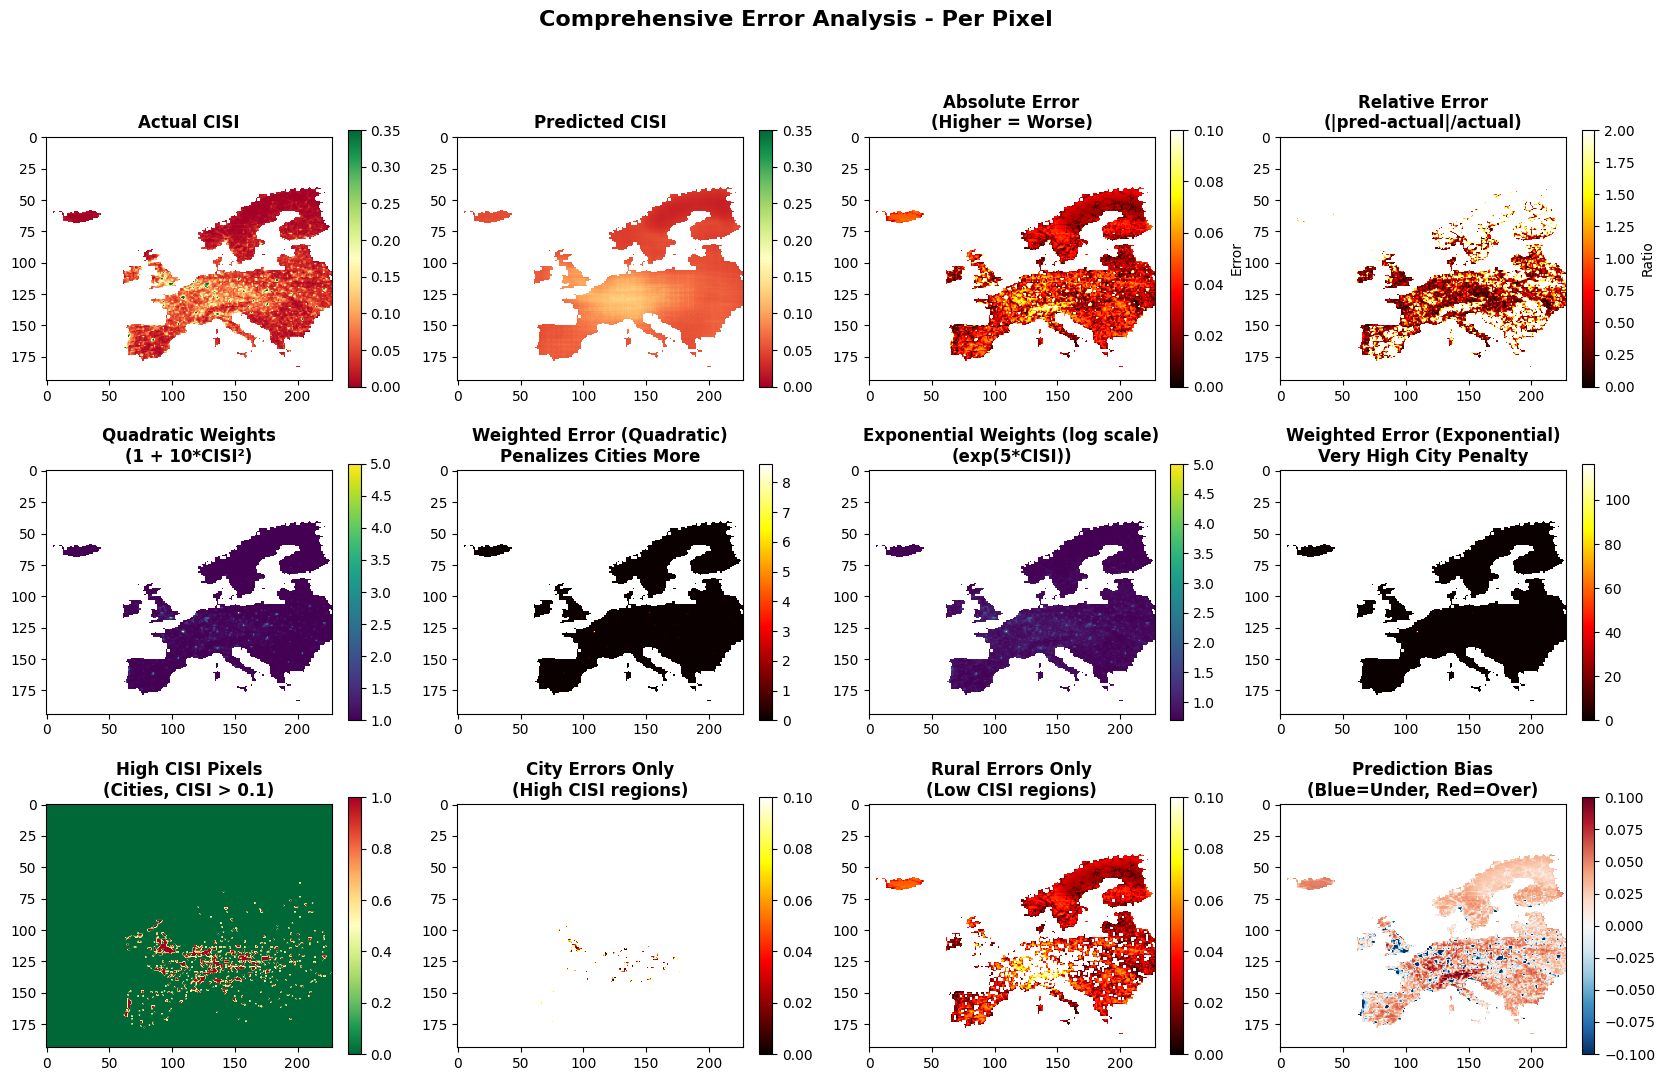

In [ ]:
# Calculate errors
print("\nCalculating errors...")
error_dict = calculate_pixel_errors(predictions, actuals, threshold_high_cisi=HIGH_CISI_THRESHOLD)

# Analyze
print("Analyzing spatial patterns...")
stats = analyze_spatial_errors(error_dict, actuals, predictions)

# Print report
print_error_report(stats)

# Visualize
print("\nGenerating visualizations...")
visualize_error_maps(error_dict, actuals, predictions)

# Compare two experiments

In [ ]:
# Load baseline
with rasterio.open('READY_data\labels\CISI_025deg_corrected.tif') as src:
    baseline_pred = src.read(1)

# Current predictions already loaded as 'predictions'
exp2_pred = predictions

# Compare
baseline_errors = calculate_pixel_errors(baseline_pred, actuals, HIGH_CISI_THRESHOLD)
exp2_errors = calculate_pixel_errors(exp2_pred, actuals, HIGH_CISI_THRESHOLD)

baseline_stats = analyze_spatial_errors(baseline_errors, actuals, baseline_pred)
exp2_stats = analyze_spatial_errors(exp2_errors, actuals, exp2_pred)

print("\n" + "="*80)
print("BASELINE vs EXP2 COMPARISON")
print("="*80)
print(f"\nOverall MAE:  {baseline_stats['overall']['mae']:.4f} -> {exp2_stats['overall']['mae']:.4f}")
print(f"City MAE:     {baseline_stats['cities']['mae']:.4f} -> {exp2_stats['cities']['mae']:.4f}")
print(f"City Bias:    {baseline_stats['cities']['mean_prediction'] - baseline_stats['cities']['mean_cisi']:.4f} -> {exp2_stats['cities']['mean_prediction'] - exp2_stats['cities']['mean_cisi']:.4f}")


BASELINE vs EXP2 COMPARISON

Overall MAE:  0.0000 -> 0.0364
City MAE:     0.0000 -> 0.0733
City Bias:    0.0000 -> -0.0718


C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_37052\1116066042.py:12: RuntimeWarning: invalid value encountered in divide
  absolute_error / actuals,
C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_37052\1116066042.py:12: RuntimeWarning: divide by zero encountered in divide
  absolute_error / actuals,


In [ ]:
print(f"Prediction min: {np.nanmin(predictions):.4f}")
print(f"Prediction max: {np.nanmax(predictions):.4f}")
print(f"Prediction mean: {np.nanmean(predictions):.4f}")
print(f"Model file: {MODEL_PTH}")
print(f"Actual CISI min: {np.nanmin(actuals):.4f}")
print(f"Actual CISI max: {np.nanmax(actuals):.4f}")

Prediction min: 0.0231
Prediction max: 0.1373
Prediction mean: 0.0650
Model file: models\cisi_model_exp27.pth
Actual CISI min: 0.0000
Actual CISI max: 1.0000


In [ ]:
checkpoint = torch.load(MODEL_PTH, map_location='cpu')
print(checkpoint['config'])
print(f"Train loss: {checkpoint.get('train_loss', 'N/A')}")
print(f"Val loss: {checkpoint.get('val_loss', 'N/A')}")

{'dropout': 0.3}
Train loss: [0.02159081146764825, 0.009235830797857586, 0.008475338455739638, 0.007871817695851994, 0.007690465519979796, 0.00753892762055183, 0.00733362643623212, 0.007026378792748105, 0.006813244326915217, 0.006937114907828654, 0.006763697399495282, 0.0065066736635295734, 0.006669099453599161, 0.006668760650634965, 0.006564379186875768, 0.00637277261660303, 0.006227771895343825, 0.0063605632128243975, 0.006264052085028398, 0.006045010690921105, 0.006211639822604472, 0.006174829411914185, 0.006091735343723839, 0.0061500149571193045, 0.005948257517700877, 0.005742818869544105, 0.006087653545175223, 0.005964984316472589, 0.005836124767099301, 0.00597407832044808, 0.005719371649417901, 0.005734245168613958, 0.00559267634447764, 0.005674542389628821, 0.005794235312179881, 0.005671293843512567]
Val loss: [0.008995649002089694, 0.007518269470892847, 0.007536559038468309, 0.006770956191561512, 0.007680219919043216, 0.007626296691218945, 0.00679760768606856, 0.006738220473650

In [ ]:
print(f"INPUT_TYPE: {INPUT_TYPE}")
print(f"MODEL_PTH or PREDICTION_TIF: {MODEL_PTH if INPUT_TYPE == 'pth' else PREDICTION_TIF}")

INPUT_TYPE: pth
MODEL_PTH or PREDICTION_TIF: models\cisi_model_exp27.pth


# Per Pixel Analysis

In [ ]:
# Calculate errors
absolute_error = np.abs(predictions - actuals)
relative_error = np.where(actuals > 0.01, absolute_error / actuals, np.nan)
bias = predictions - actuals

# Get valid data
valid_mask = ~np.isnan(absolute_error)
abs_err_flat = absolute_error[valid_mask]
rel_err_flat = relative_error[valid_mask]
bias_flat = bias[valid_mask]
actuals_flat = actuals[valid_mask]
preds_flat = predictions[valid_mask]

# Create comprehensive analysis plots
fig = plt.figure(figsize=(20, 12))

# 1. Error Distribution
ax1 = plt.subplot(3, 4, 1)
ax1.hist(abs_err_flat, bins=100, edgecolor='black', alpha=0.7)
ax1.axvline(abs_err_flat.mean(), color='red', linestyle='--', label=f'Mean: {abs_err_flat.mean():.4f}')
ax1.axvline(np.median(abs_err_flat), color='green', linestyle='--', label=f'Median: {np.median(abs_err_flat):.4f}')
ax1.set_xlabel('Absolute Error')
ax1.set_ylabel('Frequency')
ax1.set_title('Absolute Error Distribution')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Relative Error Distribution
ax2 = plt.subplot(3, 4, 2)
ax2.hist(rel_err_flat[np.isfinite(rel_err_flat)], bins=100, range=(0, 5), edgecolor='black', alpha=0.7)
ax2.set_xlabel('Relative Error (|pred-actual|/actual)')
ax2.set_ylabel('Frequency')
ax2.set_title('Relative Error Distribution')
ax2.grid(alpha=0.3)

# 3. Bias Distribution
ax3 = plt.subplot(3, 4, 3)
ax3.hist(bias_flat, bins=100, edgecolor='black', alpha=0.7, color='orange')
ax3.axvline(0, color='black', linestyle='-', linewidth=2)
ax3.axvline(bias_flat.mean(), color='red', linestyle='--', label=f'Mean: {bias_flat.mean():.4f}')
ax3.set_xlabel('Bias (pred - actual)')
ax3.set_ylabel('Frequency')
ax3.set_title('Prediction Bias\n(+Over, -Under)')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Error vs Actual CISI
ax4 = plt.subplot(3, 4, 4)
ax4.scatter(actuals_flat, abs_err_flat, alpha=0.1, s=1)
ax4.set_xlabel('Actual CISI')
ax4.set_ylabel('Absolute Error')
ax4.set_title('Error vs Actual Value')
ax4.grid(alpha=0.3)

# Add binned trend line
bins = np.linspace(0, actuals_flat.max(), 20)
bin_means_x = []
bin_means_y = []
for i in range(len(bins)-1):
    mask = (actuals_flat >= bins[i]) & (actuals_flat < bins[i+1])
    if mask.sum() > 0:
        bin_means_x.append(actuals_flat[mask].mean())
        bin_means_y.append(abs_err_flat[mask].mean())
ax4.plot(bin_means_x, bin_means_y, 'r-', linewidth=2, label='Binned mean')
ax4.legend()

# 5. Predictions vs Actuals Scatter
ax5 = plt.subplot(3, 4, 5)
ax5.scatter(actuals_flat, preds_flat, alpha=0.1, s=1)
ax5.plot([0, actuals_flat.max()], [0, actuals_flat.max()], 'r--', linewidth=2, label='Perfect prediction')
ax5.set_xlabel('Actual CISI')
ax5.set_ylabel('Predicted CISI')
ax5.set_title('Predictions vs Actuals')
ax5.legend()
ax5.grid(alpha=0.3)

# 6. Error by CISI Range
ax6 = plt.subplot(3, 4, 6)
cisi_ranges = [(0, 0.05), (0.05, 0.1), (0.1, 0.15), (0.15, 0.2), (0.2, 1.0)]
range_errors = []
range_labels = []
for low, high in cisi_ranges:
    mask = (actuals_flat >= low) & (actuals_flat < high)
    if mask.sum() > 0:
        range_errors.append(abs_err_flat[mask].mean())
        range_labels.append(f'{low:.2f}-{high:.2f}')
ax6.bar(range_labels, range_errors, edgecolor='black')
ax6.set_xlabel('CISI Range')
ax6.set_ylabel('Mean Absolute Error')
ax6.set_title('Error by CISI Level')
ax6.set_xticklabels(range_labels, rotation=45)
ax6.grid(alpha=0.3, axis='y')

# 7. Cumulative Error Distribution
ax7 = plt.subplot(3, 4, 7)
sorted_errors = np.sort(abs_err_flat)
cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
ax7.plot(sorted_errors, cumulative, linewidth=2)
ax7.axhline(0.5, color='red', linestyle='--', label='50th percentile')
ax7.axhline(0.9, color='orange', linestyle='--', label='90th percentile')
ax7.axhline(0.95, color='purple', linestyle='--', label='95th percentile')
ax7.set_xlabel('Absolute Error')
ax7.set_ylabel('Cumulative Probability')
ax7.set_title('Cumulative Error Distribution')
ax7.legend()
ax7.grid(alpha=0.3)

# 8. Residuals QQ Plot
ax8 = plt.subplot(3, 4, 8)
stats.probplot(bias_flat, dist="norm", plot=ax8)
ax8.set_title('Q-Q Plot (Normality Check)')
ax8.grid(alpha=0.3)

# 9. Error Percentiles
ax9 = plt.subplot(3, 4, 9)
percentiles = [50, 75, 90, 95, 99]
percentile_values = [np.percentile(abs_err_flat, p) for p in percentiles]
ax9.bar([str(p) for p in percentiles], percentile_values, edgecolor='black')
ax9.set_xlabel('Percentile')
ax9.set_ylabel('Absolute Error')
ax9.set_title('Error Percentiles')
ax9.grid(alpha=0.3, axis='y')

# 10. High vs Low CISI Comparison
ax10 = plt.subplot(3, 4, 10)
low_cisi_mask = actuals_flat <= 0.1
high_cisi_mask = actuals_flat > 0.1
data_to_plot = [abs_err_flat[low_cisi_mask], abs_err_flat[high_cisi_mask]]
ax10.boxplot(data_to_plot, labels=['Low CISI\n(≤0.1)', 'High CISI\n(>0.1)'])
ax10.set_ylabel('Absolute Error')
ax10.set_title('Error: Low vs High CISI')
ax10.grid(alpha=0.3, axis='y')

# 11. Overprediction vs Underprediction
ax11 = plt.subplot(3, 4, 11)
over_mask = bias_flat > 0
under_mask = bias_flat < 0
over_pct = over_mask.sum() / len(bias_flat) * 100
under_pct = under_mask.sum() / len(bias_flat) * 100
ax11.bar(['Overprediction', 'Underprediction'], 
         [abs(bias_flat[over_mask]).mean(), abs(bias_flat[under_mask]).mean()],
         color=['red', 'blue'], alpha=0.7, edgecolor='black')
ax11.set_ylabel('Mean Absolute Bias')
ax11.set_title(f'Over: {over_pct:.1f}% | Under: {under_pct:.1f}%')
ax11.grid(alpha=0.3, axis='y')

# 12. Error Statistics Table
ax12 = plt.subplot(3, 4, 12)
ax12.axis('off')
stats_text = f"""
ERROR STATISTICS

Absolute Error:
  Mean:   {abs_err_flat.mean():.4f}
  Median: {np.median(abs_err_flat):.4f}
  Std:    {abs_err_flat.std():.4f}
  Max:    {abs_err_flat.max():.4f}

Bias:
  Mean:   {bias_flat.mean():.4f}
  Median: {np.median(bias_flat):.4f}

Percentiles:
  50th: {np.percentile(abs_err_flat, 50):.4f}
  90th: {np.percentile(abs_err_flat, 90):.4f}
  95th: {np.percentile(abs_err_flat, 95):.4f}
  99th: {np.percentile(abs_err_flat, 99):.4f}

Critical Errors (>0.1):
  Count: {(abs_err_flat > 0.1).sum():,}
  Pct:   {(abs_err_flat > 0.1).sum()/len(abs_err_flat)*100:.1f}%
"""
ax12.text(0.1, 0.9, stats_text, fontsize=10, verticalalignment='top', fontfamily='monospace')

plt.tight_layout()
plt.savefig('per_pixel_error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n{'='*80}")
print("PER-PIXEL ERROR ANALYSIS COMPLETE")
print(f"{'='*80}")

# Full Dataset Analysis

In [ ]:
# Use paths from config
gdp_path = DATA_PATHS['gdp']
pop_path = DATA_PATHS['pop']
lc_path = DATA_PATHS['lc']
cisi_path = ACTUAL_CISI
model_path = MODEL_PTH

# Load model
checkpoint = torch.load(model_path, map_location=device)
config = checkpoint['config']
model = CNN(config).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Load data
with rasterio.open(gdp_path) as src:
    gdp = src.read(1).astype(np.float32)
with rasterio.open(pop_path) as src:
    pop = src.read(1).astype(np.float32)
with rasterio.open(lc_path) as src:
    lc = src.read().astype(np.float32)
with rasterio.open(cisi_path) as src:
    cisi_data = src.read(1).astype(np.float32)

# Generate predictions
print("Generating predictions on full dataset...")
predictions = np.full(gdp.shape, np.nan, dtype=np.float32)
valid_mask = ~np.isnan(gdp) & ~np.isnan(pop) & ~np.isnan(cisi_data)
valid_indices = np.argwhere(valid_mask)

with torch.no_grad():
    for idx, (i, j) in enumerate(valid_indices):
        if idx % 2000 == 0:
            print(f"  {idx}/{len(valid_indices)}")
        
        patch_size = 32
        half = 16
        i_start = max(0, i - half)
        i_end = min(gdp.shape[0], i + half)
        j_start = max(0, j - half)
        j_end = min(gdp.shape[1], j + half)
        
        gdp_patch = gdp[i_start:i_end, j_start:j_end].copy()
        pop_patch = pop[i_start:i_end, j_start:j_end].copy()
        lc_patch = lc[:, i_start:i_end, j_start:j_end].copy()
        
        gdp_patch = np.nan_to_num(gdp_patch, nan=0.0, posinf=0.0, neginf=0.0)
        pop_patch = np.nan_to_num(pop_patch, nan=0.0, posinf=0.0, neginf=0.0)
        
        pad_i = patch_size - gdp_patch.shape[0]
        pad_j = patch_size - gdp_patch.shape[1]
        
        if pad_i > 0 or pad_j > 0:
            gdp_patch = np.pad(gdp_patch, ((0, pad_i), (0, pad_j)))
            pop_patch = np.pad(pop_patch, ((0, pad_i), (0, pad_j)))
            lc_patch = np.pad(lc_patch, ((0, 0), (0, pad_i), (0, pad_j)))
        
        input_tensor = np.stack([gdp_patch, pop_patch, *lc_patch], axis=0)
        input_tensor = torch.FloatTensor(input_tensor).unsqueeze(0).to(device)
        
        predictions[i, j] = model(input_tensor).item()

# Metrics
valid = ~np.isnan(predictions) & ~np.isnan(cisi_data)
preds = predictions[valid]
acts = cisi_data[valid]

print(f"\n{'='*80}")
print("FULL DATASET EVALUATION")
print(f"{'='*80}")
print(f"Total pixels: {valid.sum():,}")
print(f"R²: {r2_score(acts, preds):.4f}")
print(f"MAE: {mean_absolute_error(acts, preds):.4f}")
print(f"Predictions: [{preds.min():.4f}, {preds.max():.4f}]")
print(f"Actuals: [{acts.min():.4f}, {acts.max():.4f}]")

for threshold in [0.1, 0.2, 0.3]:
    mask = acts > threshold
    if mask.sum() > 0:
        print(f"\nCISI > {threshold}: {mask.sum()}")
        print(f"  MAE: {mean_absolute_error(acts[mask], preds[mask]):.4f}")

In [ ]:
# After generating predictions
print(f"Predictions - NaN count: {np.isnan(predictions).sum()}")
print(f"Predictions - Valid count: {(~np.isnan(predictions)).sum()}")
print(f"Predictions - Non-zero valid: {((~np.isnan(predictions)) & (predictions != 0)).sum()}")

# Check if predictions align with input mask
input_valid = ~np.isnan(gdp) & ~np.isnan(pop) & ~np.isnan(cisi_data)
pred_valid = ~np.isnan(predictions)
print(f"Input valid: {input_valid.sum()}")
print(f"Pred valid: {pred_valid.sum()}")
print(f"Mismatch: {(input_valid & ~pred_valid).sum()}")

Predictions - NaN count: 32288
Predictions - Valid count: 11944
Predictions - Non-zero valid: 11944
Input valid: 11944
Pred valid: 11944
Mismatch: 0


In [ ]:
# Create side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Actual CISI
im1 = axes[0].imshow(cisi_data, cmap='RdYlGn', vmin=0, vmax=0.8)
axes[0].set_title('Actual CISI', fontsize=16)
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046)

# Predicted CISI
im2 = axes[1].imshow(predictions, cmap='RdYlGn', vmin=0, vmax=0.8)
axes[1].set_title('Predicted CISI', fontsize=16)
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], fraction=0.046)

# Absolute Error
error = np.abs(predictions - cisi_data)
im3 = axes[2].imshow(error, cmap='hot', vmin=0, vmax=0.2)
axes[2].set_title('Absolute Error', fontsize=16)
axes[2].axis('off')
plt.colorbar(im3, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.savefig('full_dataset_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nMetrics:")
print(f"R² = {r2_score(acts, preds):.4f}")
print(f"MAE = {mean_absolute_error(acts, preds):.4f}")
print(f"Max error = {np.nanmax(error):.4f}")

# Rural vs City MAE

In [ ]:
# Generate predictions on ALL training data
model.eval()
all_preds = []
all_actuals = []
all_indices = []

with torch.no_grad():
    for inputs, targets, indices in train_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        all_preds.extend(outputs.cpu().numpy().flatten())
        all_actuals.extend(targets.cpu().numpy().flatten())
        all_indices.extend(indices)

all_preds = np.array(all_preds)
all_actuals = np.array(all_actuals)

# Split by city/rural
city_mask = all_actuals > 0.1
rural_mask = all_actuals <= 0.1

print(f"\n{'='*80}")
print("TRAINING SET: CITY vs RURAL")
print(f"{'='*80}")

print(f"\n🏙️ CITIES (CISI > 0.1):")
print(f"  Count: {city_mask.sum():,}")
print(f"  Actual mean: {all_actuals[city_mask].mean():.4f}")
print(f"  Pred mean: {all_preds[city_mask].mean():.4f}")
print(f"  MAE: {mean_absolute_error(all_actuals[city_mask], all_preds[city_mask]):.4f}")

print(f"\n🌾 RURAL (CISI ≤ 0.1):")
print(f"  Count: {rural_mask.sum():,}")
print(f"  Actual mean: {all_actuals[rural_mask].mean():.4f}")
print(f"  Pred mean: {all_preds[rural_mask].mean():.4f}")
print(f"  MAE: {mean_absolute_error(all_actuals[rural_mask], all_preds[rural_mask]):.4f}")